In [3]:
import numpy as np
import opt_einsum as oe
import matplotlib.pyplot as plt
import scipy as sp

from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal import integration_scheme
# from quant_rotor.core.dense.de_solve_one_thermal_dense import integration_scheme as int_fast
import quant_rotor.CCC_integration_methods.Dense.thermofield_boltz_funcs as bz

from quant_rotor.Hamiltonian_models.Dense.heisenberg_operators import heisenberg_operators
from quant_rotor.Hamiltonian_models.Dense.hamiltonian import hamiltonian_dense as ham
from quant_rotor.Hamiltonian_models.Dense.rotor_operators import rotor_operators
from quant_rotor.Hamiltonian_models.Dense.NO_transfrorm import NO_transform

from quant_rotor.Hamiltonian_models.Dense.combine_hamiltonian import combine_hamiltonian as ham_comb

from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import U as U_stat

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_periodic import t_periodic
from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_periodic_fast import t_periodic as t_periodic_fast

from z_non_periodic.Non_Periodic import t_non_periodic

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_exact import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy, intermediate_normalisation

In [4]:
np.set_printoptions(precision=15)
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(threshold=np.inf)

# Check TF Rotor

In [ ]:
state = 7
state_2 = state**2

site = 3

g = 0.1

periodic = False

In [ ]:
K, V = rotor_operators(state, g)
H = ham(site, K, V, periodic)

In [ ]:
eig_val, eig_vec = np.linalg.eigh(H)

In [ ]:
U, _ = bz.thermofield_change_of_basis(K)
I = np.eye(state)

K_prim = oe.contract('pq,mw->pmqw', K, I,  optimize='optimal')
K_grouped = K_prim.reshape(state_2, state_2)

V_tensor = V.reshape(state, state, state, state)
V_prim = oe.contract('pqrs,mw,nv->pnqmrvsw', V_tensor, I, I,  optimize='optimal')
V_grouped = V_prim.reshape(state_2**2, state_2**2)

In [ ]:
time_TF, energy_TF, one_max_TF, two_max_TF = integration_scheme(site, state_2, g, t_init=0,t_final=10,nof_points=10000, Import=True, K_import=K_grouped, V_import=V_grouped.reshape(state_2, state_2, state_2, state_2), periodic=periodic)

In [ ]:
plt.plot(time_TF, eig_val/site, label=f"Exact U g = {g}")
plt.plot(time_TF, energy_TF/site, label=f"Prim g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TF[-1]/site)
print("Exact: ", np.min(eig_val)/site)

# Primitive Spin Ham.

In [5]:
state = 2
state_2 = 4

site = 5

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.7

In [7]:
K, V = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
H = ham(site, K, V, V, True)

In [8]:
U, _ = bz.thermofield_change_of_basis(K)
I = np.eye(state)

K_prim = oe.contract('pq,mw->pmqw', K, I,  optimize='optimal')
K_grouped = K_prim.reshape(state_2, state_2)

V_tensor = V.reshape(state, state, state, state)
V_prim = oe.contract('pqrs,mw,nv->pnqmrvsw', V_tensor, I, I,  optimize='optimal')
V_grouped = V_prim.reshape(state_2**2, state_2**2)

[0.707106781186548 0.707106781186548]
[1.]


In [9]:
eig_val_ED, eig_vec_ED = np.linalg.eigh(H)

In [10]:
time_TF, energy_TD_TF_CCC, one_max_TD_TF_CC, two_max_TD_TF_CC = integration_scheme(site, state_2, g, t_init=0,t_final=10,nof_points=100000, Import=True, K_import=K_grouped, V_import=V_grouped.reshape(state_2, state_2, state_2, state_2))

TypeError: integration_scheme() got an unexpected keyword argument 'Import'

In [ ]:
ED_U_val = np.array([U_stat(eig_val_ED, x) for x in time_TF])

In [ ]:
plt.plot(time_TF, ED_U_val/site, label=f"Exact U g = {g}")
plt.plot(time_TF, energy_TD_TF_CCC/site, label=f"Prim g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TD_TF_CCC[-1]/site)
print("Exact: ", np.min(eig_val_ED)/site)

# Primitive Non-Periodic TF

In [ ]:
state = 2
state_2 = 4

site = 7

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.1

periodic = False

In [ ]:
K, V = heisenberg_operators(site, J_x, J_y, J_z, h_x, h_y, h_z, g)
H = ham(site, K, V, periodic)

In [ ]:
U, _ = bz.thermofield_change_of_basis(K)
I = np.eye(state)

K_prim = oe.contract('pq,mw->pmqw', K, I,  optimize='optimal')
K_grouped = K_prim.reshape(state_2, state_2)

V_tensor = V.reshape(state, state, state, state)
V_prim = oe.contract('pqrs,mw,nv->pnqmrvsw', V_tensor, I, I,  optimize='optimal')
V_grouped = V_prim.reshape(state_2**2, state_2**2)

In [ ]:
eig_val_ED, eig_vec_ED = np.linalg.eigh(H)

In [ ]:
time_TF, energy_TD_TF_CCC, one_max_TD_TF_CC, two_max_TD_TF_CC = integration_scheme(site, state_2, g, t_init=0,t_final=10,nof_points=100000, Import=True, K_import=K_grouped, V_import=V_grouped.reshape(state_2, state_2, state_2, state_2), periodic=periodic)

In [ ]:
ED_U_val = np.array([U_stat(eig_val_ED, x) for x in time_TF])

In [ ]:
plt.plot(time_TF, ED_U_val/site, label=f"Exact U g = {g}")
plt.plot(time_TF, energy_TD_TF_CCC/site, label=f"Prim g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TD_TF_CCC[-1]/site)
print("Exact: ", np.min(eig_val_ED)/site)

In [ ]:
print("TF", energy_TD_TF_CCC[-1])
print("Exact: ", np.min(eig_val_ED))

# Combined Ham.

In [ ]:
state = 2
state_2 = 4

site = 6
site_comb = 3

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 1

In [ ]:
K, V = heisenberg_operators(site, J_x, J_y, J_z, h_x, h_y, h_z, g)
H = ham(site, K, V, periodic)

In [ ]:
H_comb, _, _, _ = ham_comb(site, site_comb, K, V, False)

In [ ]:
eig_val, eig_vec = np.linalg.eigh(H)
eig_val_comb, eig_vec_comb = np.linalg.eigh(H_comb)

In [ ]:
eig_val

In [ ]:
eig_val_comb

# TF Combined Ham

In [ ]:
n_comb_sites = 2

state = 2
state_2 = state**2
state_comb = state**2
state_comb_2 = state_comb**2

site_comb = 3
site = n_comb_sites * site_comb

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 2

periodic = False

In [ ]:
K, V = heisenberg_operators(site, J_x, J_y, J_z, h_x, h_y, h_z, g)
H = ham(site, K, V, periodic)

In [ ]:
H_comb, K_comb, V_comb, _ = ham_comb(site, site_comb, K, V, periodic)

In [ ]:
eig_val, eig_vec = np.linalg.eigh(H)
eig_val_comb, eig_vec_comb = np.linalg.eigh(H_comb)

In [ ]:
if np.allclose(np.sort(eig_val), np.sort(eig_val_comb), atol=1e-20) == False:
    raise ValueError("Incorect Combined.")

In [ ]:
U, _ = bz.thermofield_change_of_basis(K)
I = np.eye(state)

K_prim = oe.contract('pq,mw->pmqw', K, I,  optimize='optimal')
K_grouped = K_prim.reshape(state_2, state_2)

V_tensor = V.reshape(state, state, state, state)
V_prim = oe.contract('pqrs,mw,nv->pnqmrvsw', V_tensor, I, I,  optimize='optimal')
V_grouped = V_prim.reshape(state_2**2, state_2**2)

In [ ]:
U_comb, _ = bz.thermofield_change_of_basis(K_comb)
I_comb = np.eye(state_comb)

K_prim_comb = oe.contract('pq,mw->pmqw', K_comb, I_comb,  optimize='optimal')
K_grouped_comb = K_prim_comb.reshape(state_comb_2, state_comb_2)

V_tensor_comb = V_comb.reshape(state_comb, state_comb, state_comb, state_comb)
V_prim_comb = oe.contract('pqrs,mw,nv->pnqmrvsw', V_tensor_comb, I_comb, I_comb,  optimize='optimal')
V_grouped_comb = V_prim_comb.reshape(state_comb_2**2, state_comb_2**2)

In [ ]:
time_TF, energy_TF, one_max_TF, two_max_TF = integration_scheme(site, state_2, g, t_init=0,t_final=10,nof_points=100000, Import=True, K_import=K_grouped, V_import=V_grouped.reshape(state_2, state_2, state_2, state_2), periodic=periodic)

In [ ]:
time_TF_comb, energy_TF_comb, one_max_TF_comb, two_max_TF_comb = integration_scheme(site_comb, state_comb_2, g, t_init=0,t_final=10,nof_points=100000, Import=True, K_import=K_grouped_comb, V_import=V_grouped_comb.reshape(state_comb_2, state_comb_2, state_comb_2, state_comb_2), periodic=periodic)

In [ ]:
ED_U_val = np.array([U_stat(eig_val_ED, x) for x in time_TF])

In [ ]:
plt.plot(time_TF, ED_U_val/site, label=f"Exact U g = {g}")
plt.plot(time_TF, energy_TF/site, label=f"Prim g = {g}")
plt.plot(time_TF_comb, energy_TF_comb/site, label=f"Prim_comb g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TF[-1]/site)
print("Exact: ", np.min(eig_val_ED)/site)

# Combined NO Transform.

In [7]:
state = 2
state_2 = state**2

n_comb_sites = 4
site_comb = 2
site = n_comb_sites * site_comb

state_comb = state**n_comb_sites
state_comb_2 = state_comb**2

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.69

periodic = False

In [8]:
K, V = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
# K, V = rotor_operators(state, g)
H = ham(site, K, V, periodic)

In [9]:
H_comb, K_comb, V_comb, _ = ham_comb(site, site_comb, K, V, periodic)

In [10]:
K_NO, V_NO, basis = NO_transform(state_comb, state_comb, H_comb, K_comb, V_comb)

[-0.                -0.                -0.                -0.                 0.                 0.                 0.                 0.                 0.                 0.                 0.                 0.                 0.004755094794801  0.064202100586108  0.064202100586109  0.866840704032982]
[[ 0.               +0.j -0.               -0.j  0.               +0.j -0.               -0.j  0.               +0.j  0.               +0.j -0.               -0.j  0.               +0.j  0.               +0.j  0.               +0.j  0.               +0.j  0.               +0.j -0.               -0.j  0.               +0.j  1.               +0.j  0.               +0.j]
 [-0.180247913977247+0.j -0.075264056161071+0.j -0.019505734782571+0.j -0.               +0.j -0.               +0.j  0.               +0.j -0.               +0.j -0.000000000000623+0.j -0.004495198016806+0.j -0.034285207629061+0.j  0.076078366638944+0.j  0.280416951090157+0.j  0.815936661562479+0.j -0.               +0.j

In [11]:
V_NO_0 = V_NO * 0

In [12]:
H_NO = ham(site_comb, K_NO, V_NO, periodic)

In [13]:
eig_val, eig_vec = np.linalg.eigh(H)

In [14]:
eig_val_comb, eig_vec_comb = np.linalg.eigh(H_comb)

In [15]:
eig_val_NO, eig_vec_NO = np.linalg.eigh(H_NO)

In [16]:
eig_val_NO

array([-8.707834296377484, -8.593551633369103, -8.114282663008376, -8.087834296377489, -8.000000000000002, -7.973551633369109, -7.494282663008378, -7.380000000000004, -7.187103266738216, -7.072820603729833, -6.593551633369109, -6.567103266738214, -6.479268970360732, -6.452820603729836, -6.228565326016759, -6.114282663008381, -5.973551633369109, -5.859268970360731, -5.635013692647649, -5.608565326016758, -5.520731029639275, -5.494282663008382, -5.327834296377489, -5.213551633369107, -5.015013692647651, -4.900731029639276, -4.734282663008381, -4.707834296377489, -4.707834296377485, -4.619999999999998, -4.593551633369106, -4.593551633369104, -4.593551633369104, -4.47926897036073 , -4.114282663008384, -4.11428266300838 , -4.114282663008378, -4.087834296377485, -4.000000000000001, -4.               , -4.               , -3.999999999999997, -3.973551633369111, -3.973551633369107, -3.88571733699162 , -3.859268970360728, -3.807103266738215, -3.692820603729834, -3.520731029639272, -3.4942826630

In [17]:
eig_val_comb

array([-8.707834296377484, -8.593551633369108, -8.114282663008378, -8.087834296377489, -8.               , -7.973551633369108, -7.494282663008378, -7.38             , -7.187103266738218, -7.072820603729837, -6.593551633369107, -6.567103266738214, -6.479268970360728, -6.452820603729834, -6.228565326016756, -6.114282663008381, -5.973551633369106, -5.859268970360729, -5.635013692647654, -5.608565326016759, -5.52073102963927 , -5.494282663008378, -5.327834296377487, -5.213551633369109, -5.015013692647651, -4.900731029639272, -4.734282663008382, -4.707834296377487, -4.707834296377487, -4.620000000000001, -4.59355163336911 , -4.593551633369107, -4.593551633369106, -4.479268970360729, -4.114282663008381, -4.11428266300838 , -4.114282663008378, -4.087834296377487, -4.000000000000005, -4.000000000000003, -4.               , -3.999999999999999, -3.973551633369107, -3.973551633369106, -3.885717336991621, -3.859268970360727, -3.807103266738215, -3.692820603729837, -3.520731029639272, -3.4942826630

In [18]:
eig_val

array([-8.707834296377484, -8.593551633369108, -8.114282663008378, -8.087834296377489, -8.               , -7.973551633369108, -7.494282663008378, -7.38             , -7.187103266738218, -7.072820603729837, -6.593551633369107, -6.567103266738214, -6.479268970360728, -6.452820603729834, -6.228565326016756, -6.114282663008381, -5.973551633369106, -5.859268970360729, -5.635013692647654, -5.608565326016759, -5.52073102963927 , -5.494282663008378, -5.327834296377487, -5.213551633369109, -5.015013692647651, -4.900731029639272, -4.734282663008382, -4.707834296377487, -4.707834296377487, -4.620000000000001, -4.59355163336911 , -4.593551633369107, -4.593551633369106, -4.479268970360729, -4.114282663008381, -4.11428266300838 , -4.114282663008378, -4.087834296377487, -4.000000000000005, -4.000000000000003, -4.               , -3.999999999999999, -3.973551633369107, -3.973551633369106, -3.885717336991621, -3.859268970360727, -3.807103266738215, -3.692820603729837, -3.520731029639272, -3.4942826630

In [19]:
eig_vec_NO[:, np.argmin(eig_val_NO)]

array([ 0.916832947018698+0.j, -0.000000000000003+0.j, -0.000000000000001+0.j, -0.146342290095413+0.j,  0.061961704725292+0.j,  0.017548696834747+0.j, -0.008117216499345+0.j, -0.001244792150886+0.j, -0.000000000000152+0.j, -0.               +0.j, -0.               +0.j,  0.               +0.j,  0.               +0.j, -0.006563868164959+0.j, -0.010033759019598+0.j,  0.021990370938477+0.j, -0.000000000000003+0.j, -0.               +0.j,  0.16171384221851 +0.j,  0.000000000000001+0.j, -0.0361921944425  +0.j,  0.110955133963995+0.j, -0.082699161044663+0.j, -0.125958766632715+0.j,  0.000000000001035+0.j,  0.               +0.j, -0.               +0.j,  0.               +0.j, -0.               +0.j,  0.034887639135315+0.j,  0.022237158542868+0.j, -0.003662842595724+0.j, -0.               +0.j,  0.253381334328534+0.j, -0.               +0.j, -0.               +0.j,  0.               +0.j,  0.               +0.j, -0.               +0.j, -0.               +0.j,  0.               +0.j, -0.      

In [20]:
t_1_exact = t_1_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_NO, eig_val_NO)
t_2_exact = t_2_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_NO, eig_val_NO)

In [24]:
t_1_exact_save = t_1_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_NO, eig_val_NO)
t_2_exact_save = t_2_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_NO, eig_val_NO)

In [25]:
E, E_0, E_1 = amplitute_energy(site_comb, state_comb, periodic, K_NO, V_NO.reshape(state_comb, state_comb, state_comb, state_comb), t_1_exact, t_2_exact)

In [20]:
# t_1_exact = t_1_amplitude_guess_ground_state(state, n_comb_sites, eig_vec, eig_val)
# t_2_exact = t_2_amplitude_guess_ground_state(state, n_comb_sites, eig_vec, eig_val)

# E, E_0, E_1 = amplitute_energy(n_comb_sites, state, periodic, K, V.reshape(state, state, state, state), t_1_exact, t_2_exact)

In [28]:
eig_val_NO[0] - E

np.complex128(1.7763568394002505e-15+0j)

In [29]:
# t_1, t_2 = t_periodic(site_comb, state_comb, g, False, Import_K_V=True, K_import=K_NO, V_import=V_NO.reshape(state_comb, state_comb, state_comb, state_comb), Import_t=True, t_1_import=t_1_exact, t_2_import=t_2_exact, periodic=periodic)

In [ ]:
time, energy, one_max, two_max = integration_scheme(site_comb, state_comb, K_NO, V_NO.reshape(state, state, state, state), V.reshape(state, state, state, state), t_init=0,t_final=10,nof_points=10000, periodic=periodic, import_guess=True, t_1_import=t_1_exact, t_2_import=t_2_exact)

(3.9889543218449357+0j)
(2, 2, 15, 15, 1, 1)
[np.float64(-8.776063778933686)]
[np.float64(-8.776080580532708)]
[np.float64(-8.776088979962488)]
[np.float64(-8.776101579449994)]
[np.float64(-8.776153726331707)]
[np.float64(-8.776170228198561)]
[np.float64(-8.776143620463507)]
[np.float64(-8.776162041528348)]
[np.float64(-8.776271718904123)]
[np.float64(-8.776255352439563)]
[np.float64(-8.776337406946631)]
[np.float64(-8.776382980242218)]
[np.float64(-8.776382980242218)]
[np.float64(-8.776550765115672)]
[np.float64(-8.776634520979563)]
[np.float64(-8.776760189324232)]
[np.float64(-8.777279656039388)]
[np.float64(-8.77744382354917)]
[np.float64(-8.777179067031392)]
[np.float64(-8.777362392163557)]
[np.float64(-8.778451207482783)]
[np.float64(-8.77828902141267)]
[np.float64(-8.779101132006474)]


KeyboardInterrupt: 

In [ ]:
t_2_exact.shape

(2, 2, 15, 15, 1, 1)

In [ ]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


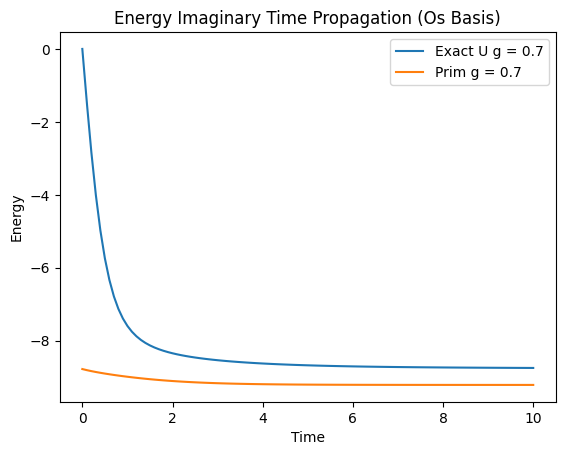

TF (-9.21115129108734+0j)
Exact:  -8.745883316068861


In [ ]:
plt.plot(time_TF, ED_U_val, label=f"Exact U g = {g}")
plt.plot(time_TF, energy_TF, label=f"Prim g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TF[-1])
print("Exact: ", np.min(ED_U_val))

In [ ]:
one_max_TF[-1]

In [ ]:
two_max_TF[-1]

In [ ]:
H_NO[0,0]

# Planar Rotor

In [14]:
n_comb_sites = 3
site_comb = 2
site = n_comb_sites * site_comb


state = 3
state_comb = state**n_comb_sites

g = 0.8

periodic = False

In [15]:
K, V = rotor_operators(state, g)
H = ham(site, K, V, periodic)

In [16]:
H_comb, K_comb, V_comb, _ = ham_comb(site, site_comb, K, V, periodic)

In [17]:
eig_val, eig_vec = np.linalg.eigh(H)

In [18]:
eig_val_comb, eig_vec_comb = np.linalg.eigh(H_comb)

In [19]:
eig_val

array([-1.838735152048101, -1.735809989269017, -0.881550908108816, -0.850738998331044, -0.789732706672519, -0.706256933929859, -0.553580694865126, -0.553580694865125, -0.368082220311971, -0.317172398896048, -0.229143378106472, -0.067968839126443, -0.067968839126442, -0.022057161159475,  0.168934312026492,  0.198846443879519,  0.259756336099178,  0.264215242439803,  0.329465042651696,  0.329465042651696,  0.444234379580004,  0.463066430931167,  0.48729379665184 ,  0.524671794770279,  0.528444744106297,  0.528444744106299,  0.538490806514106,  0.608793578151178,  0.618084394559133,  0.639721447371885,  0.646465584215656,  0.646465584215656,  0.664200560822984,  0.723079860213888,  0.727462985680895,  0.743916469114101,  0.7961203161944  ,  0.814720211940061,  0.849578896809798,  0.862483411035272,  0.933851103419983,  0.960577723869561,  1.007873575634886,  1.007873575634892,  1.032354153462538,  1.039824471715906,  1.039824471715908,  1.146379032042707,  1.163699343812267,  1.1671349018

In [20]:
eig_val_comb

array([-1.838735152048101, -1.735809989269017, -0.881550908108816, -0.850738998331044, -0.789732706672519, -0.706256933929859, -0.553580694865126, -0.553580694865125, -0.368082220311971, -0.317172398896048, -0.229143378106472, -0.067968839126443, -0.067968839126442, -0.022057161159475,  0.168934312026492,  0.198846443879519,  0.259756336099178,  0.264215242439803,  0.329465042651696,  0.329465042651696,  0.444234379580004,  0.463066430931167,  0.48729379665184 ,  0.524671794770279,  0.528444744106297,  0.528444744106299,  0.538490806514106,  0.608793578151178,  0.618084394559133,  0.639721447371885,  0.646465584215656,  0.646465584215656,  0.664200560822984,  0.723079860213888,  0.727462985680895,  0.743916469114101,  0.7961203161944  ,  0.814720211940061,  0.849578896809798,  0.862483411035272,  0.933851103419983,  0.960577723869561,  1.007873575634886,  1.007873575634892,  1.032354153462538,  1.039824471715906,  1.039824471715908,  1.146379032042707,  1.163699343812267,  1.1671349018

In [21]:
eig_vec[:, 0]

array([0.615392521941604+0.j, 0.               +0.j, 0.000000000000001+0.j, 0.000000000000001+0.j, 0.160327854895361+0.j, 0.067367909612104+0.j, 0.               +0.j, 0.067367909612105+0.j, 0.160327854895361+0.j, 0.               +0.j, 0.065824422834799+0.j, 0.089391369227825+0.j, 0.164798176038547+0.j, 0.               +0.j, 0.               +0.j, 0.080373776974325+0.j, 0.               +0.j, 0.               +0.j, 0.000000000000001+0.j, 0.089391369227825+0.j, 0.065824422834799+0.j, 0.080373776974325+0.j, 0.               +0.j, 0.               +0.j, 0.164798176038547+0.j, 0.               +0.j, 0.               +0.j, 0.               +0.j, 0.065486954234197+0.j, 0.058339687410091+0.j, 0.077129746985433+0.j, 0.               +0.j, 0.               +0.j, 0.097879562026257+0.j, 0.               +0.j, 0.               +0.j, 0.166525955649854+0.j, 0.               +0.j, 0.               +0.j, 0.               +0.j, 0.047046442948204+0.j, 0.0220043164551  +0.j, 0.               +0.j, 0.01

In [22]:
eig_vec_comb[:, 0]

array([0.615392521941604+0.j, 0.               +0.j, 0.000000000000001+0.j, 0.000000000000001+0.j, 0.160327854895361+0.j, 0.067367909612104+0.j, 0.               +0.j, 0.067367909612105+0.j, 0.160327854895361+0.j, 0.               +0.j, 0.065824422834799+0.j, 0.089391369227825+0.j, 0.164798176038547+0.j, 0.               +0.j, 0.               +0.j, 0.080373776974325+0.j, 0.               +0.j, 0.               +0.j, 0.000000000000001+0.j, 0.089391369227825+0.j, 0.065824422834799+0.j, 0.080373776974325+0.j, 0.               +0.j, 0.               +0.j, 0.164798176038547+0.j, 0.               +0.j, 0.               +0.j, 0.               +0.j, 0.065486954234197+0.j, 0.058339687410091+0.j, 0.077129746985433+0.j, 0.               +0.j, 0.               +0.j, 0.097879562026257+0.j, 0.               +0.j, 0.               +0.j, 0.166525955649854+0.j, 0.               +0.j, 0.               +0.j, 0.               +0.j, 0.047046442948204+0.j, 0.0220043164551  +0.j, 0.               +0.j, 0.01

In [23]:
t_1_exact = t_1_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_comb, eig_val_comb)
t_2_exact = t_2_amplitude_guess_ground_state(state_comb, site_comb, eig_vec_comb, eig_val_comb)

E, E_0, E_1 = amplitute_energy(site_comb, state_comb, periodic, K_comb, V_comb.reshape(state_comb, state_comb, state_comb, state_comb), t_1_exact, t_2_exact)

(-0.730018477211674+0j)
(-0.730018477211674+0j)


In [24]:
t_1_max, t_2_max, energy, t_1, t_2 = t_periodic(site_comb, state_comb, g, False, Import_K_V=True, K_import=K_comb, V_import=V_comb.reshape(state_comb, state_comb, state_comb, state_comb), Import_t=True, t_1_import=t_1_exact, t_2_import=t_2_exact, periodic=periodic)

ValueError: Diverges.

# Combined NO New method

In [ ]:
state = 2
state_2 = state**2

n_comb_sites = 6
site_comb = 2
site = n_comb_sites * site_comb

state_comb = state**n_comb_sites
state_comb_2 = state_comb**2

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.7

periodic = False

In [ ]:
K, V = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
# K, V = rotor_operators(state, g)
H = ham(n_comb_sites, K, V, periodic)

In [ ]:
H_comb, K_comb, V_comb, _ = ham_comb(n_comb_sites, 1, K, V, periodic)

In [ ]:
K_NO, V_NO, basis = NO_transform(state_comb, state_comb, H_comb, K_comb, V_comb)

In [ ]:
H_NO = ham(1, K_NO, V_NO, periodic)

In [ ]:
eig_val, eig_vec = np.linalg.eigh(H)

In [ ]:
eig_val_comb, eig_vec_comb = np.linalg.eigh(H_comb)

In [ ]:
eig_val_NO, eig_vec_NO = np.linalg.eigh(H_NO)

In [ ]:
print("ED:", eig_val)
print("Comb:", eig_val_comb)
print("NO:", eig_val_NO)

In [ ]:
eig_vec_comb[:, 0]